DTFS Coefficients a_k:
a_0 = 0.666667+0.000000j
a_1 = 0.000000-0.288675j
a_2 = 0.166667-0.000000j
a_3 = 0.000000-0.000000j
a_4 = 0.166667-0.000000j
a_5 = -0.000000+0.288675j


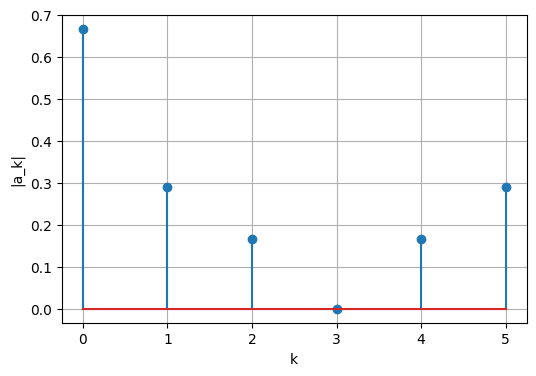

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 6
x = np.array([1, 1, 1, 1, 0, 0], dtype=complex)
n = np.arange(N)

a = np.array([(1/N) * np.sum(x * np.exp(-1j * 2*np.pi*k*n/N)) for k in range(N)])

# Print DTFS coefficients
print("DTFS Coefficients a_k:")
for k in range(N):
    print(f"a_{k} = {a[k]:.6f}")

# Plot DTFS coefficients
k = np.arange(N)

plt.figure(figsize=(6, 4))
plt.stem(k, np.abs(a))
plt.xlabel("k")
plt.ylabel("|a_k|")
plt.grid(True)
plt.show()

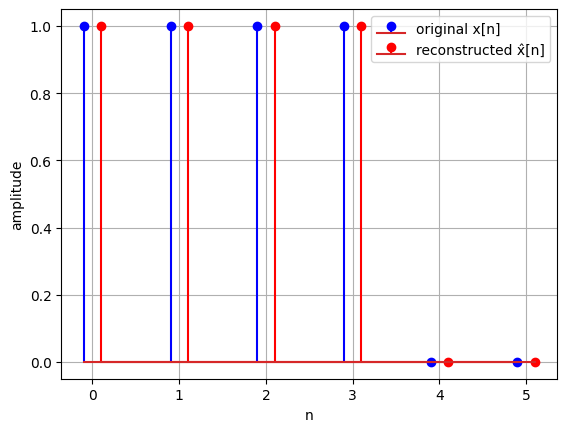

In [10]:
import numpy as np
import matplotlib.pyplot as plt

N = 6
n = np.arange(N)
x = np.array([1, 1, 1, 1, 0, 0], dtype=complex)

# DTFS analysis equation
a = np.zeros(N, dtype=complex)
for k in range(N):
    a[k] = (1/N) * np.sum(x * np.exp(-1j * 2*np.pi*k*n/N))

# DTFS synthesis equation to reconstruct
x_hat = np.zeros(N, dtype=complex)
k_arr = np.arange(N)
for nn in range(N):
    x_hat[nn] = np.sum(a * np.exp(1j * 2*np.pi*k_arr*nn/N))

# round values (0+1e-17j)
eps = 1e-17
x_hat_real = np.real(x_hat)
x_hat_imag = np.imag(x_hat)
x_hat_real[np.abs(x_hat_real) < eps] = 0
x_hat_imag[np.abs(x_hat_imag) < eps] = 0
x_hat_clean = x_hat_real + 1j * x_hat_imag

# visualisation
plt.figure()
plt.stem(n - 0.1, np.real(x), linefmt='b-', label="original x[n]")
plt.stem(n + 0.1, np.real(x_hat_clean), linefmt='r-', label="reconstructed x̂[n]")
plt.xlabel("n")
plt.ylabel("amplitude")
plt.legend()
plt.grid(True)
plt.show()